In [1]:
import pandas as pd

short_df = pd.read_csv(
    "new_diffusion/final_model/final_short_amp_candidates.csv"
)

long_df = pd.read_csv(
    "new_diffusion/final_model/final_long_amp_candidates.csv"
)

print(short_df.shape)
print(long_df.shape)

(5343, 9)
(1749, 9)


In [2]:
master_df = pd.concat(
    [
        short_df,
        long_df
    ],
    ignore_index=True
)

print(master_df.shape)

(7092, 9)


In [3]:
master_df = master_df.drop_duplicates(
    subset=["Sequence"]
)

print(master_df.shape)

(7091, 9)


In [4]:
master_df.to_csv(
    "MASTER_AMP_LIBRARY.csv",
    index=False
)

In [ ]:
import pandas as pd

amp_df = pd.read_csv(
    "data/processed_data&code/clean_amp_dataset.csv"
)

print(amp_df.shape)

(8400, 6)


In [6]:
train_set = set(
    amp_df["Sequence"]
)

print(len(train_set))

8400


In [7]:
generated_set = set(
    master_df["Sequence"]
)

print(len(generated_set))

7091


In [8]:
novel = [
    seq
    for seq in generated_set
    if seq not in train_set
]

print(
    "Novel:",
    len(novel)
)

print(
    "Generated:",
    len(generated_set)
)

print(
    "Novelity Ratio:",
    len(novel) /
    len(generated_set)
)

Novel: 7011
Generated: 7091
Novelity Ratio: 0.9887180933577775


In [9]:
novel_df = master_df[
    master_df["Sequence"].isin(novel)
].copy()

novel_df.to_csv(
    "MASTER_NOVEL_AMP_LIBRARY.csv",
    index=False
)

print(novel_df.shape)

(7011, 9)


In [12]:
novel_df["Final_Score"] = (
    novel_df["AMP_Probability"]
    -
    novel_df["Hemolysis_Probability"]
)

top100_novel = novel_df.head(100)

print(top100_novel.shape)

(100, 9)


In [14]:
top100_novel.to_csv(
    "TOP100_NOVEL_MASTER_CANDIDATES.csv",
    index=False
)

In [15]:
top100_novel[
    [
        "Sequence",
        "AMP_Probability",
        "Hemolysis_Probability",
        "Final_Score"
    ]
].head(10)

,Sequence,AMP_Probability,Hemolysis_Probability,Final_Score
0,KILIKKLKKHIK,0.999444,0.000757,0.998687
1,KILKKIWKKIKQ,0.999614,0.001013,0.998601
2,KKLKKFKFLKKAQW,0.999491,0.000973,0.998518
3,KWLKKFKKLKQA,0.999600,0.001430,0.998170
4,KRILKWILKFKK,0.999793,0.001644,0.998149
5,KWLKKIIKKLKK,0.999667,0.001589,0.998078
6,KRKLLHRLKRK,0.999441,0.001406,0.998034
7,LLRLLRKKTRKKIW,0.999792,0.001810,0.997982
8,ILKKLWRKIKRK,0.999808,0.001880,0.997928
9,GIIKKLFKKLVSKTAR,0.998970,0.001046,0.997923


In [16]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

train_sequences = amp_df["Sequence"].tolist()
generated_sequences = novel_df["Sequence"].tolist()

print(len(train_sequences))
print(len(generated_sequences))

8400
7011


In [17]:
from collections import Counter

amino_acids = "ACDEFGHIKLMNPQRSTVWY"

def aa_frequency(sequences):

    counts = Counter()

    total = 0

    for seq in sequences:

        counts.update(seq)

        total += len(seq)

    freq = {
        aa: counts[aa] / total
        for aa in amino_acids
    }

    return freq

train_freq = aa_frequency(
    train_sequences
)

generated_freq = aa_frequency(
    generated_sequences
)

print(train_freq)
print(generated_freq)

{'A': 0.07088461675788443, 'C': 0.06018842036000836, 'D': 0.026467602817634186, 'E': 0.03275168196030625, 'F': 0.043478482639721296, 'G': 0.08614595181865943, 'H': 0.01982137301008411, 'I': 0.06288669784902907, 'K': 0.11528122784377534, 'L': 0.09692886034756262, 'M': 0.012435539732008508, 'N': 0.03506740593008962, 'P': 0.039658048160937716, 'Q': 0.02702868131251562, 'R': 0.07742883229363788, 'S': 0.0508643159177969, 'T': 0.03777588484629, 'V': 0.052695472096546306, 'W': 0.02786009762765811, 'Y': 0.02435080667785423}
{'A': 0.06438574782296955, 'C': 0.08453701240878445, 'D': 0.020261128008233976, 'E': 0.026153276821130785, 'F': 0.039082466954239, 'G': 0.09040603208011935, 'H': 0.022938326144025165, 'I': 0.057666732199234426, 'K': 0.129315030472644, 'L': 0.08510945866244174, 'M': 0.009477165754993003, 'N': 0.03732465219553376, 'P': 0.034057660949913846, 'Q': 0.02761619502492165, 'R': 0.07565542204901066, 'S': 0.051271524557366055, 'T': 0.040840281712944224, 'V': 0.05021336633090863, 'W': 

In [18]:
import pandas as pd

freq_df = pd.DataFrame({
    "AA": list(amino_acids),
    "Training": [
        train_freq[aa]
        for aa in amino_acids
    ],
    "Generated": [
        generated_freq[aa]
        for aa in amino_acids
    ]
})

freq_df.head()

,AA,Training,Generated
0,A,0.070885,0.064386
1,C,0.060188,0.084537
2,D,0.026468,0.020261
3,E,0.032752,0.026153
4,F,0.043478,0.039082


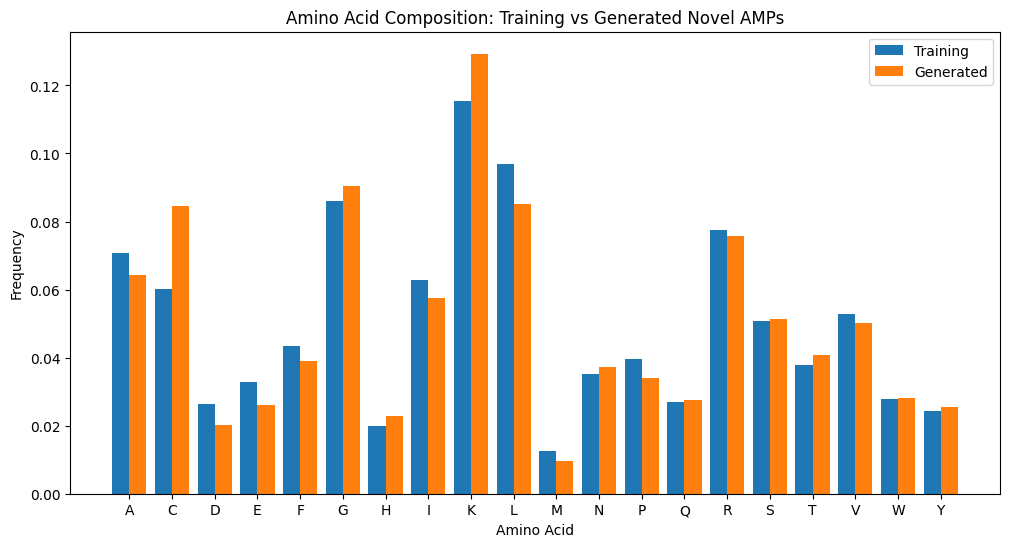

In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(amino_acids))

width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    freq_df["Training"],
    width,
    label="Training"
)

plt.bar(
    x + width/2,
    freq_df["Generated"],
    width,
    label="Generated"
)

plt.xticks(
    x,
    amino_acids
)

plt.ylabel(
    "Frequency"
)

plt.xlabel(
    "Amino Acid"
)

plt.title(
    "Amino Acid Composition: Training vs Generated Novel AMPs"
)

plt.legend()

plt.show()

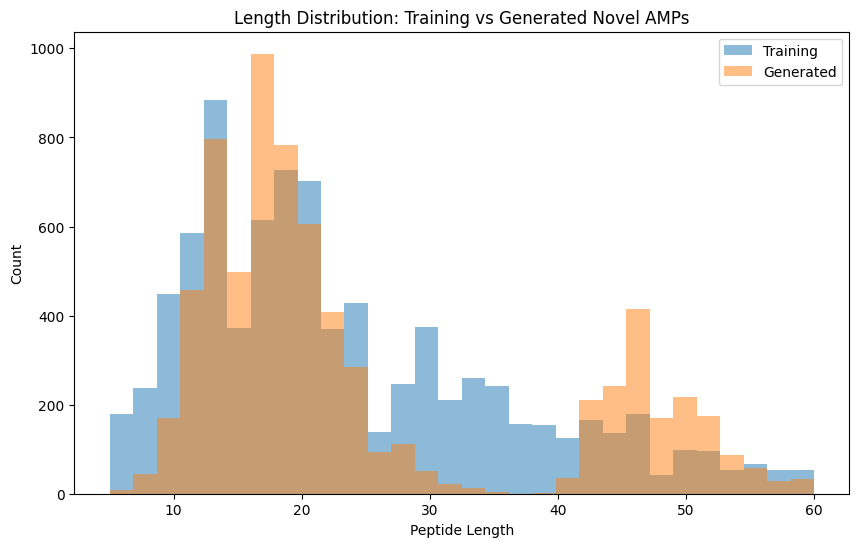

In [21]:
train_lengths = [
    len(seq)
    for seq in train_sequences
]

generated_lengths = [
    len(seq)
    for seq in generated_sequences
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    train_lengths,
    bins=30,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_lengths,
    bins=30,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Peptide Length")
plt.ylabel("Count")
plt.title("Length Distribution: Training vs Generated Novel AMPs")

plt.legend()

plt.show()

<Axes: >

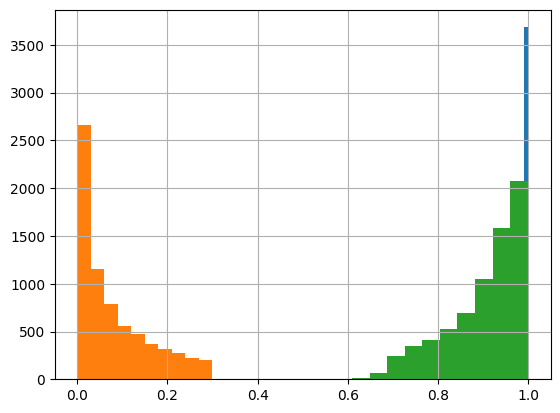

In [22]:
novel_df["AMP_Probability"].hist()
novel_df["Hemolysis_Probability"].hist()
novel_df["Final_Score"].hist()

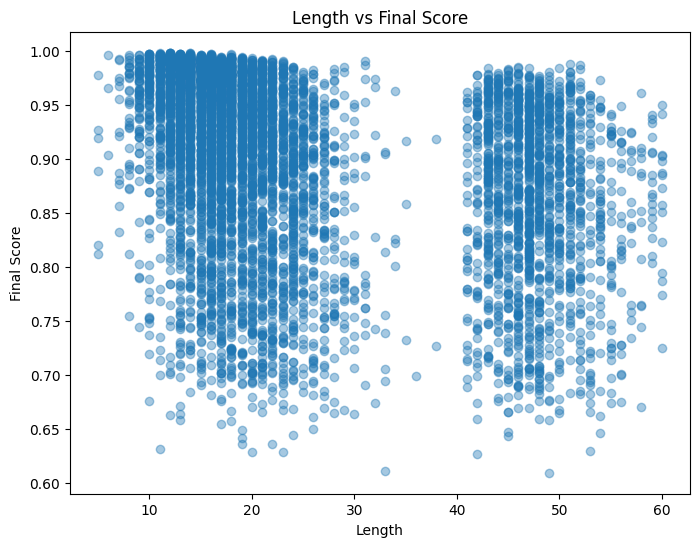

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    novel_df["Length"],
    novel_df["Final_Score"],
    alpha=0.4
)

plt.xlabel("Length")
plt.ylabel("Final Score")
plt.title("Length vs Final Score")
plt.show()

In [ ]:
import numpy as np

amp_embeddings = np.load(
    "embeddings/amp_embeddings.npy"
)

print(
    amp_embeddings.shape
)

(8400, 1280)


In [26]:
sequences = novel_df["Sequence"].tolist()

print(len(sequences))

7011


In [27]:
import torch
import esm

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()

batch_converter = alphabet.get_batch_converter()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

model.eval()

ESM2(
  (embed_tokens): Embedding(33, 1280, padding_idx=1)
  (layers): ModuleList(
    (0-32): 33 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=1280, out_features=5120, bias=True)
      (fc2): Linear(in_features=5120, out_features=1280, bias=True)
      (final_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=660, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((1280,), eps=1

In [28]:
data = [
    (str(i), seq)
    for i, seq
    in enumerate(sequences)
]

print(len(data))

7011


In [29]:
import numpy as np

embeddings = []

for i in range(
    0,
    len(data),
    16
):

    batch = data[
        i:i+16
    ]

    labels, strs, tokens = (
        batch_converter(batch)
    )

    tokens = tokens.to(device)

    with torch.no_grad():

        results = model(
            tokens,
            repr_layers=[33]
        )

    reps = results[
        "representations"
    ][33]

    for j, seq in enumerate(strs):

        emb = reps[
            j,
            1:len(seq)+1
        ].mean(0)

        embeddings.append(
            emb.cpu().numpy()
        )

    if i % 500 == 0:

        print(
            f"Processed {i}/{len(data)}"
        )

Processed 0/7011
Processed 2000/7011
Processed 4000/7011
Processed 6000/7011


In [30]:
novel_embeddings = np.array(
    embeddings
)

print(
    novel_embeddings.shape
)

(7011, 1280)


In [31]:
np.save(
    "novel_amp_embeddings.npy",
    novel_embeddings
)

In [32]:
print(
    novel_embeddings.shape
)

print(
    novel_embeddings.mean()
)

print(
    novel_embeddings.std()
)

(7011, 1280)
-0.0014858464
0.2639698


In [33]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 91 kB 201 kB/s            
     |████████████████████████████████| 73 kB 185 kB/s            


In [ ]:
import numpy as np

train_embeddings = np.load(
    "embeddings/amp_embeddings.npy"
)

novel_embeddings = np.load(
    "novel_amp_embeddings.npy"
)

print(train_embeddings.shape)
print(novel_embeddings.shape)

(8400, 1280)
(7011, 1280)


In [36]:
np.random.seed(42)

train_idx = np.random.choice(
    len(train_embeddings),
    2000,
    replace=False
)

novel_idx = np.random.choice(
    len(novel_embeddings),
    2000,
    replace=False
)

train_sample = train_embeddings[
    train_idx
]

novel_sample = novel_embeddings[
    novel_idx
]

print(train_sample.shape)
print(novel_sample.shape)

(2000, 1280)
(2000, 1280)


In [37]:
X = np.vstack(
    [
        train_sample,
        novel_sample
    ]
)

labels = np.array(
    ["Training"] * len(train_sample)
    +
    ["Novel"] * len(novel_sample)
)

print(X.shape)

(4000, 1280)


In [38]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_2d = reducer.fit_transform(
    X
)

print(
    embedding_2d.shape
)

/usr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-18 14:42:33.446940: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 14:42:33.883689: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 14:42:34.952992: I tensorflow/core/util/port.cc:153] oneDNN custo

(4000, 2)


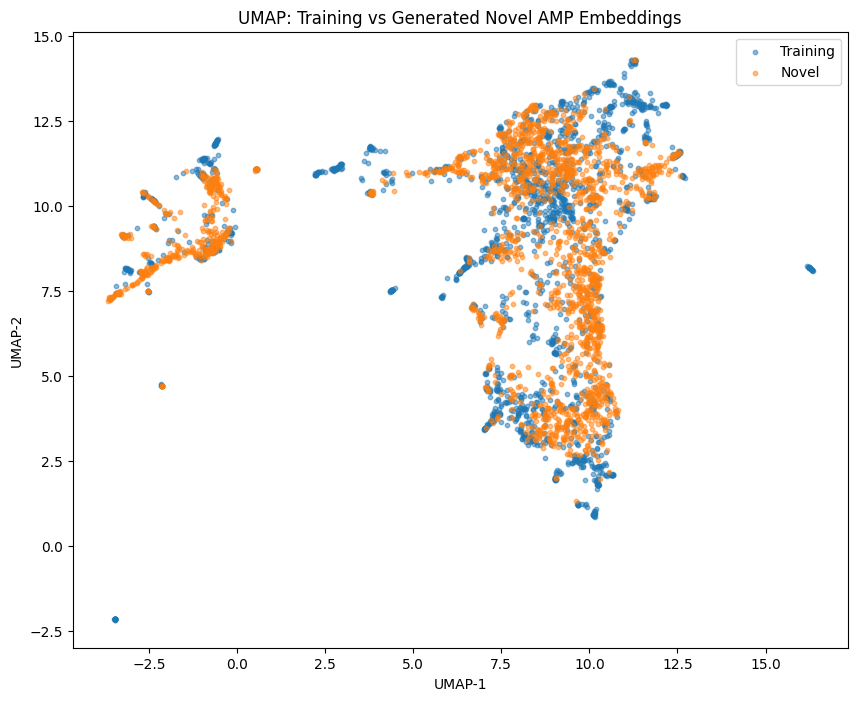

In [39]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(10,8)
)

for label in [
    "Training",
    "Novel"
]:

    mask = (
        labels == label
    )

    plt.scatter(
        embedding_2d[mask,0],
        embedding_2d[mask,1],
        alpha=0.5,
        s=10,
        label=label
    )

plt.title(
    "UMAP: Training vs Generated Novel AMP Embeddings"
)

plt.xlabel(
    "UMAP-1"
)

plt.ylabel(
    "UMAP-2"
)

plt.legend()

plt.show()